<a href="https://colab.research.google.com/github/cedizen/etude_access_eau_potable/blob/main/ecommerce_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ecommerce data exploration.
Let's review some data and retrieve some key insights.

# **Introduction**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import kagglehub
import os

import math

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


from sklearn.model_selection import train_test_split

# **Configurations**

In [ ]:
METRICS = {
    "Quantity": {
        "TotalQuantity": ("Quantity", "sum"),
        "MeanQuantity": ("Quantity", "mean")
    },
    "Amount": {
        "TotalAmount": ("TotalAmount", "sum"),
        "MedianAmount": ("TotalAmount", "median")
    },
    "Rating": {
        "MeanRating": ("Rating", "mean")
    },
    "Reviews": {
        "NumberReviews": ("Reviews", "sum"),
        "MeanReviews": ("Reviews", "mean")
    }
}

PRODUCT = "Product"
BRAND = "Brand"
CATEGORY = "Category"
PLATFORM = "Platform"
RATING = "Rating"
REVIEWS = "Reviews"

# **Functions**

In [ ]:
def checknull(df):
  return df.isnull().sum()

def check_duplicates(df):
  return df.duplicated().sum()

def check_columns(df, col):
  return df[col].value_counts()

def grouped_features(df,
                   grouped_feature,
                   numerical_feature=None,
                   metrics=None):
  grouped_df = df.groupby(grouped_feature, as_index=False)[numerical_feature].agg(**metrics)
  return grouped_df

def top_performer(df,
                  features=None,
                  sorted_feature=None,
                  ascendingDirection=False):
  sorted_df = df.loc[:, features].sort_values(sorted_feature, ascending=ascendingDirection)
  return sorted_df

def plot_bar_df(df,
                x=None,
                y=None,
                title=None,
                xlabel=None,
                ylabel=None, ax=None, stacked=False):
  ax = df.plot(kind="bar", x=x, y=y, legend=False, stacked=stacked, ax=ax)
  ax.set_title(title)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  return ax

def nrows_ncols(n_per_col, n_el):
  nrows = math.ceil(n_el/n_per_col)
  return nrows

In [ ]:
# help to flatten the metrics to fit to the agg part
# take the whole metrics as parameters
# return a dictionnary fitted to groupby aggregations
def flatten_metrics(metrics):
  return {
      metric_name: agg
      for metric_group in metrics.values()
      for metric_name, agg in metric_group.items()
  }

In [ ]:
# Select the accurated metrics depeding on the features we want to take
def select_accurated_metrics(metrics, features=None):
  selected_metrics = {}
  if features is not None:
    for name, agg in metrics.items():
        if name in features:
          selected_metrics[name] = agg
    return selected_metrics
  else:
    return metrics

In [ ]:
def grouped_metrics(df, feature_grouped, metrics, as_index):
  flat_metrics = flatten_metrics(metrics)
  return df.groupby(feature_grouped, as_index=as_index).agg(**flat_metrics)

In [ ]:
def plot_metrics(plots, nrows=None, ncols=None, figsize=(12, 6)):
    n_plots = len(plots)

    # Create subplots if requested
    if nrows is not None and ncols is not None:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

        # Normalize axes to a flat list
        if nrows * ncols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
    else:
        fig, ax = plt.subplots(figsize=figsize)
        axes = [ax]

    for ax, (title, spec) in zip(axes, plots.items()):
        df = spec["df"]
        x = spec["x"]
        y = spec["y"]

        df.plot(kind="bar", x=x, y=y, ax=ax, legend=False)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

# **Data loading and preview**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jockeroika/ecommerce-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-data' dataset.
Path to dataset files: /kaggle/input/ecommerce-data


In [ ]:
file = os.listdir(path)

In [ ]:
df_ecommerce = pd.read_csv(f"{path}/{file[0]}")

In [ ]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      10000 non-null  object 
 1   Product      10000 non-null  object 
 2   Category     10000 non-null  object 
 3   Brand        10000 non-null  object 
 4   Platform     10000 non-null  object 
 5   City         10000 non-null  object 
 6   Price        10000 non-null  float64
 7   Quantity     10000 non-null  int64  
 8   TotalAmount  10000 non-null  float64
 9   Rating       10000 non-null  float64
 10  Reviews      10000 non-null  int64  
 11  OrderDate    10000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 937.6+ KB


In [ ]:
df_ecommerce.describe()

,Price,Quantity,TotalAmount,Rating,Reviews
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10027.986331,3.006200,30199.572439,3.005592,2520.072200
std,5728.261196,1.415472,23861.789828,1.154845,1443.849734
min,105.590000,1.000000,113.550000,1.000000,0.000000
25%,4999.862500,2.000000,11066.910000,2.010000,1275.000000
50%,10063.600000,3.000000,23671.630000,3.005000,2537.500000
75%,14938.430000,4.000000,44648.580000,4.000000,3767.000000
max,19999.340000,5.000000,99993.800000,5.000000,5000.000000


In [ ]:
df_ecommerce.head()

,OrderID,Product,Category,Brand,Platform,City,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate
0,ORD100000,Samsung Galaxy A14,Electronics,Samsung,Souq,Cairo,16284.02,1,16284.02,1.39,1684,2024-11-11
1,ORD100001,Nike Air Max,Fashion,Nike,Jumia,Alexandria,6645.20,2,13290.40,2.56,3604,2024-06-22
2,ORD100002,Bluetooth Headset,Accessories,JBL,Jumia,Casablanca,8882.92,3,26648.76,4.98,1257,2024-05-27
3,ORD100003,HP Pavilion Laptop,Computers,HP,Souq,Dubai,3665.44,1,3665.44,1.44,662,2024-07-25
4,ORD100004,iPhone 13,Electronics,Apple,Souq,Casablanca,5210.37,2,10420.74,3.73,2424,2024-02-19


# **Data cleaning**

## **Nulls**

In [ ]:
checknull(df_ecommerce)

,0
OrderID,0
Product,0
Category,0
Brand,0
Platform,0
City,0
Price,0
Quantity,0
TotalAmount,0
Rating,0


In [ ]:
check_duplicates(df_ecommerce)

np.int64(0)

In [ ]:
print(f"{df_ecommerce["OrderID"].nunique()} / {len(df_ecommerce["OrderID"])}")

10000 / 10000


Numerical columns

In [ ]:
numerical_columns = df_ecommerce.select_dtypes(include=[int, float]).columns.tolist()
numerical_columns

['Price', 'Quantity', 'TotalAmount', 'Rating', 'Reviews']

In [ ]:
for col in numerical_columns:
  display(df_ecommerce[col])

,Price
0,16284.02
1,6645.20
2,8882.92
3,3665.44
4,5210.37
...,...
9995,3571.93
9996,2974.55
9997,8646.20
9998,4960.53


,Quantity
0,1
1,2
2,3
3,1
4,2
...,...
9995,1
9996,4
9997,1
9998,4


,TotalAmount
0,16284.02
1,13290.40
2,26648.76
3,3665.44
4,10420.74
...,...
9995,3571.93
9996,11898.20
9997,8646.20
9998,19842.12


,Rating
0,1.39
1,2.56
2,4.98
3,1.44
4,3.73
...,...
9995,1.05
9996,2.60
9997,3.20
9998,3.42


,Reviews
0,1684
1,3604
2,1257
3,662
4,2424
...,...
9995,2154
9996,1796
9997,4001
9998,685


Order Date

In [ ]:
df_ecommerce["OrderDate"].count().sum()

np.int64(10000)

In [ ]:
df_ecommerce["OrderDate"] = pd.to_datetime(df_ecommerce["OrderDate"], errors="coerce")
df_ecommerce["OrderDate"].count().sum()

np.int64(10000)

In [ ]:
df_ecommerce["OrderDate"].value_counts()

,count
OrderDate,
2024-12-02,46
2024-01-30,42
2024-07-26,42
2024-10-03,41
2024-07-14,41
...,...
2024-10-26,17
2024-06-03,16
2024-08-07,16


categorical columns

In [ ]:
object_columns = df_ecommerce.select_dtypes(include=["object"]).columns.tolist()
object_columns

['OrderID', 'Product', 'Category', 'Brand', 'Platform', 'City']

In [ ]:
for col in object_columns:
  display(df_ecommerce[col].value_counts())

,count
OrderID,
ORD109983,1
ORD109982,1
ORD109981,1
ORD109980,1
ORD109979,1
...,...
ORD100004,1
ORD100003,1
ORD100002,1


,count
Product,
Samsung Galaxy A14,1043
Xiaomi Redmi Note 12,1030
Bluetooth Headset,1029
Smartwatch FitPro,1020
Nike Air Max,1005
T-shirt Cotton,997
HP Pavilion Laptop,991
Adidas Running Shoes,968
Dell Inspiron 3501,962


,count
Category,
Electronics,3028
Fashion,2970
Computers,1953
Accessories,1029
Wearables,1020


,count
Brand,
Samsung,1043
Xiaomi,1030
JBL,1029
FitPro,1020
Nike,1005
Generic,997
HP,991
Adidas,968
Dell,962


,count
Platform,
Souq,3371
Jumia,3341
Amazon,3288


,count
City,
Cairo,1705
Casablanca,1689
Riyadh,1679
Alexandria,1657
Dubai,1648
Giza,1622


After having checked all cleaning methodology, all dataframe have been cleaned up and are ready to be explored and exploited for further analysis.

## **Outlier detection**

Detecting outliers is an important step in data cleaning, as extreme values can significantly affect statistical results, summary metrics, and model performance—especially for methods that are sensitive to deviations from typical ranges.

However, the presence of outliers does not necessarily indicate corrupted or erroneous data. In many cases, these values may represent legitimate observations or even define a distinct subgroup within the dataset.

In this context, outlier detection is primarily performed using boxplots and histograms. These visual tools allow us to assess the overall distribution of the data and to evaluate how far potential outliers lie from the median and the central tendency of the distribution.

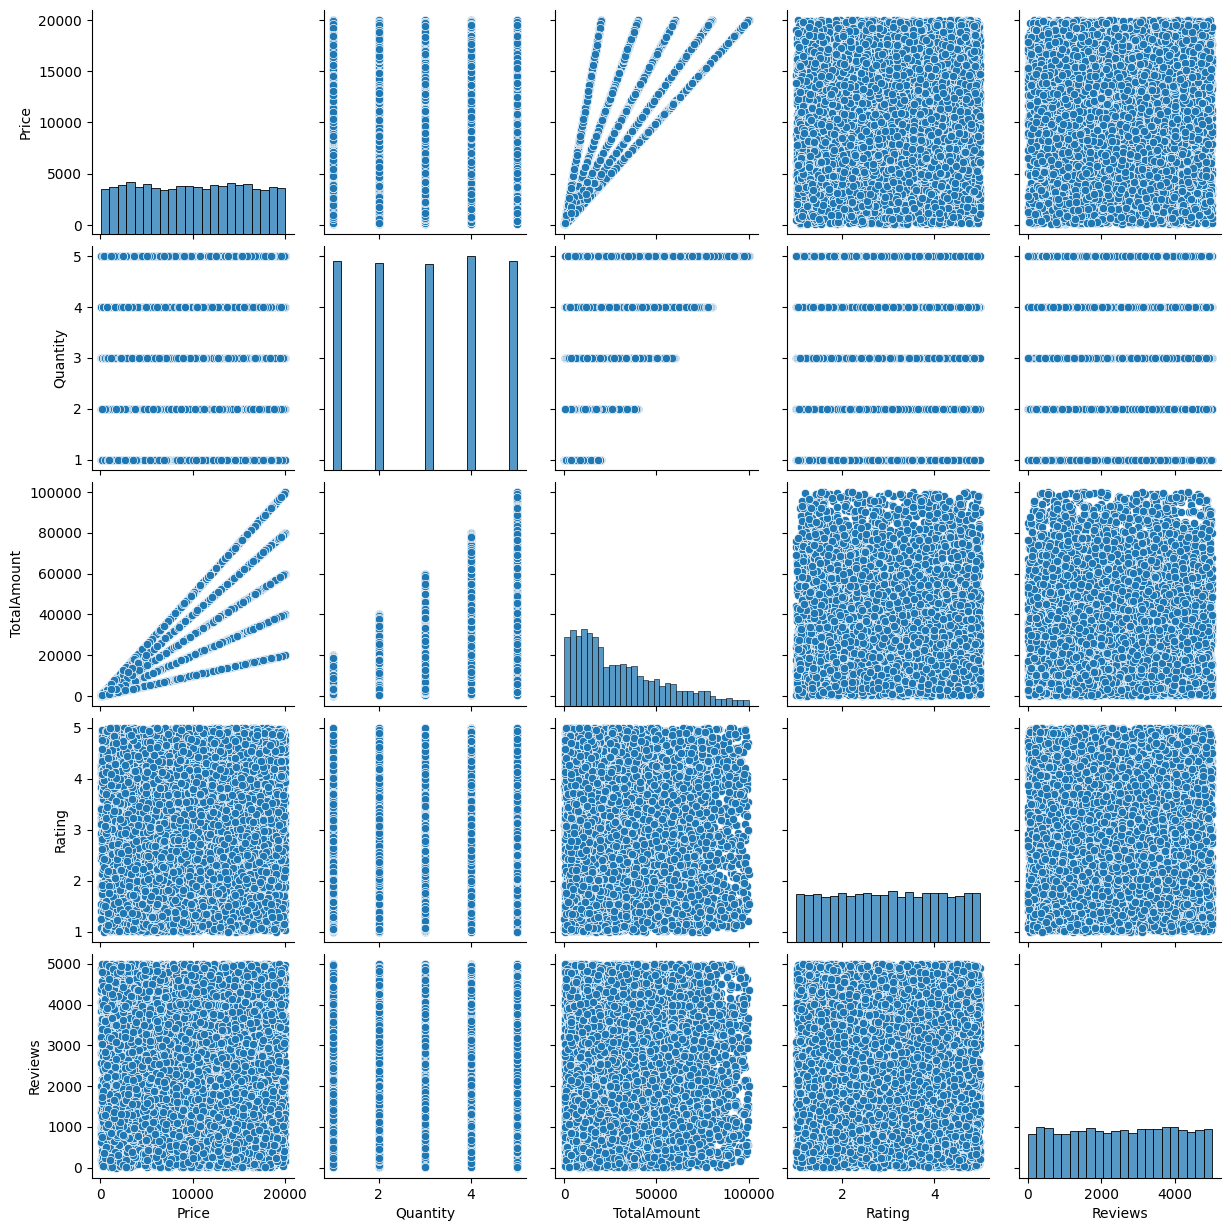

In [ ]:
sns.pairplot(df_ecommerce)
plt.show()

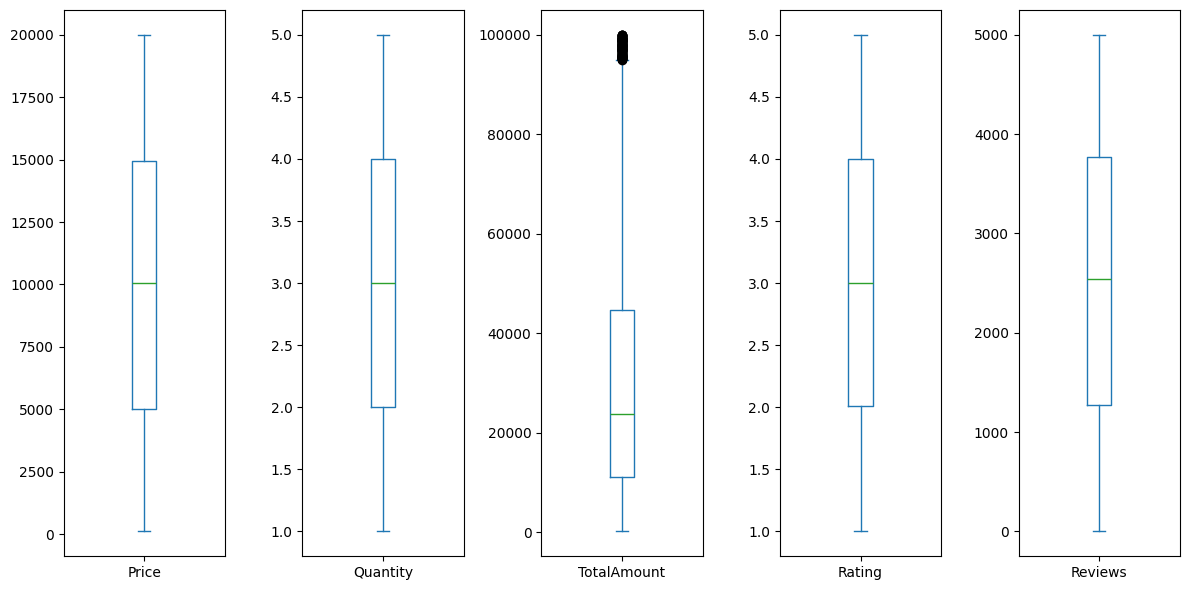

In [ ]:
fig, axes = plt.subplots(1, len(numerical_columns), figsize=(12,6))

for i, num_col in enumerate(numerical_columns):
  df_ecommerce[num_col].plot(kind="box", ax=axes[i])
plt.tight_layout()
plt.show()

In [ ]:
Q3_amount = df_ecommerce["TotalAmount"].quantile(0.75)
Q1_amount = df_ecommerce["TotalAmount"].quantile(0.25)
iqr_amount = Q3_amount - Q1_amount

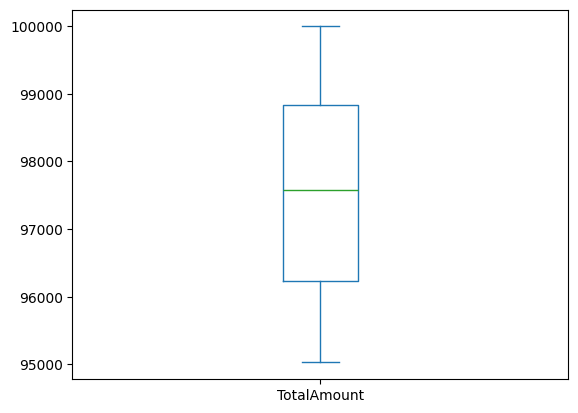

In [ ]:
upper_whiskers = Q3_amount + 1.5 * iqr_amount
outliers_amount = df_ecommerce.loc[df_ecommerce["TotalAmount"] > upper_whiskers, "TotalAmount"]
outliers_amount.plot(kind="box")
plt.show()

In [ ]:
outliers_amount.describe()

,TotalAmount
count,89.000000
mean,97510.808427
std,1495.158576
min,95028.950000
25%,96227.500000
50%,97579.000000
75%,98828.650000
max,99993.800000


Based on the previous scatter plots, most numerical features appear to be well distributed. However the total amount variable shows the presence of several outlier observations.

As a result, using the median rather than the mean is more appropriate for future analyses, as it provides a more robust measure of central tendency in the presence of outliers.

# **Data Analysis Exploration**

In [ ]:
def decompose_date(df, column):
  month = df[column].dt.month
  month_name = df[column].dt.month_name
  year = df[column].dt.year
  return month, month_name, year

In [ ]:
month, month_name, year = decompose_date(df_ecommerce, "OrderDate")
new_column = {
    "OrderMonth": month,
    "OrderMonthName": month_name,
    "OrderYear": year
}
for name, value in new_column.items():
  df_ecommerce[name] = value

In [ ]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   OrderID         10000 non-null  object        
 1   Product         10000 non-null  object        
 2   Category        10000 non-null  object        
 3   Brand           10000 non-null  object        
 4   Platform        10000 non-null  object        
 5   City            10000 non-null  object        
 6   Price           10000 non-null  float64       
 7   Quantity        10000 non-null  int64         
 8   TotalAmount     10000 non-null  float64       
 9   Rating          10000 non-null  float64       
 10  Reviews         10000 non-null  int64         
 11  OrderDate       10000 non-null  datetime64[ns]
 12  OrderMonth      10000 non-null  int32         
 13  OrderMonthName  10000 non-null  object        
 14  OrderYear       10000 non-null  int32         
dtypes: 

## **Global turnover**

In [ ]:
global_turnover = df_ecommerce["TotalAmount"].sum()
print(f"Global turnover is {global_turnover}$")

Global turnover is 301995724.39$


# **Products analysis**

What are the products that peformed the best accross time ?

In [ ]:
selected_products_metrics = select_accurated_metrics(METRICS)
selected_products_metrics

{'Quantity': {'TotalQuantity': ('Quantity', 'sum'),
  'MeanQuantity': ('Quantity', 'mean')},
 'Amount': {'TotalAmount': ('TotalAmount', 'sum'),
  'MedianAmount': ('TotalAmount', 'median')},
 'Rating': {'MeanRating': ('Rating', 'mean')},
 'Reviews': {'NumberReviews': ('Reviews', 'sum'),
  'MeanReviews': ('Reviews', 'mean')}}

In [ ]:
grouped_products_metrics = grouped_metrics(df_ecommerce,
                                           PRODUCT, selected_products_metrics, as_index=False)
grouped_products_metrics

,Product,TotalQuantity,MeanQuantity,TotalAmount,MedianAmount,MeanRating,NumberReviews,MeanReviews
0,Adidas Running Shoes,2904,3.000000,30269021.82,25485.760,2.968740,2464191,2545.651860
1,Bluetooth Headset,3043,2.957240,29200970.13,20736.160,2.996463,2632079,2557.899903
2,Dell Inspiron 3501,2913,3.028067,28060270.42,22390.900,2.992152,2455185,2552.167360
3,HP Pavilion Laptop,2979,3.006054,29482727.14,22818.800,3.066105,2526089,2549.030272
4,Nike Air Max,3040,3.024876,30727637.51,24260.400,2.957343,2505699,2493.232836
5,Samsung Galaxy A14,3056,2.930010,30004263.23,21768.700,3.045618,2604628,2497.246405
6,Smartwatch FitPro,3111,3.050000,31420413.20,24440.215,3.029706,2518191,2468.814706
7,T-shirt Cotton,3036,3.045135,30507500.40,24430.720,2.948756,2534748,2542.375125
8,Xiaomi Redmi Note 12,3187,3.094175,33772598.37,27123.780,2.986650,2609353,2533.352427
9,iPhone 13,2793,2.924607,28550322.17,22616.660,3.064597,2350559,2461.318325


## **Products quantity analysis**

In [ ]:
df_products_quantity = grouped_products_metrics.loc[:, ["Product", "MeanQuantity", "TotalQuantity"]]

In [ ]:
df_top_products_quantity = df_products_quantity.sort_values("TotalQuantity", ascending=False).head(10)

In [ ]:
df_top_products_mean_quantity = df_products_quantity.sort_values("MeanQuantity", ascending=False).head(10)

In [ ]:
bar_plots_product_quantity = {
    "Top products per quantity": {
        "df": df_top_products_quantity,
        "x": "Product",
        "y": "TotalQuantity",
    },
    "Top products per mean quantity": {
        "df": df_top_products_mean_quantity,
        "x": "Product",
        "y": "MeanQuantity",
    },
}

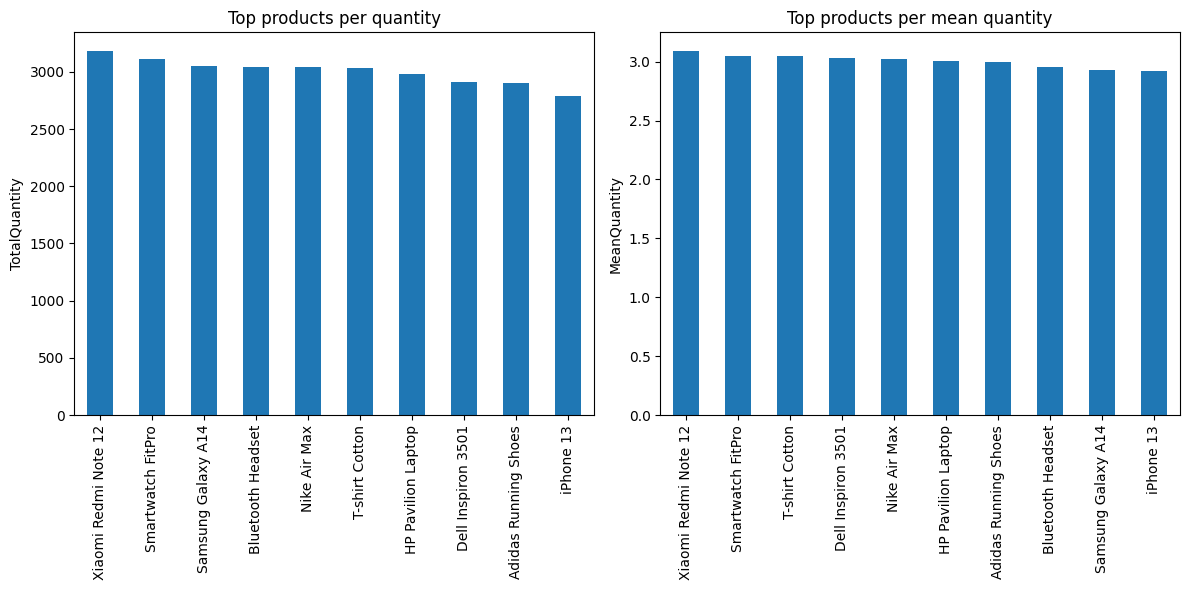

In [ ]:
plot_metrics(bar_plots_product_quantity, nrows=1, ncols=2)

## **Products amount analysis**

In [ ]:
df_products_amount = grouped_products_metrics.loc[:, ["Product", "TotalAmount", "MedianAmount"]]

In [ ]:
df_top_products_amount = df_products_amount.sort_values("TotalAmount", ascending=False).head(10)

In [ ]:
df_top_products_median_amount = df_products_amount.sort_values("MedianAmount", ascending=False)

In [ ]:
bar_plots_product_amount = {
    "Top products per amount": {
        "df": df_top_products_amount,
        "x": "Product",
        "y": "TotalAmount",
    },
    "Top products per median amount": {
        "df": df_top_products_median_amount,
        "x": "Product",
        "y": "MedianAmount",
    },
}

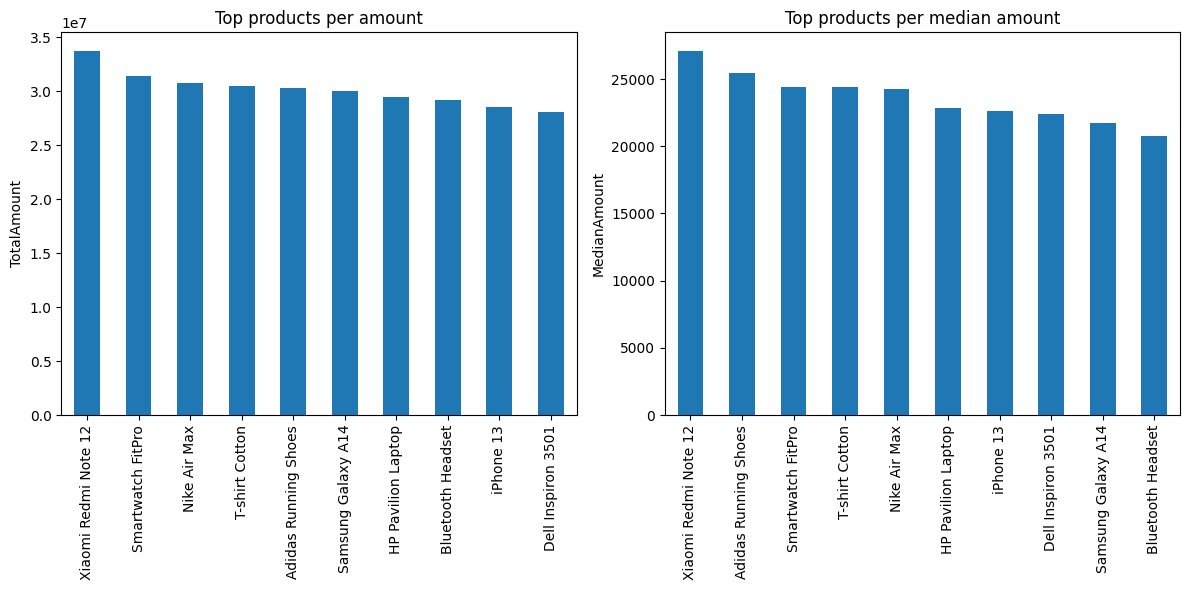

In [ ]:
plot_metrics(bar_plots_product_amount, ncols=2, nrows=1)

## **Top products per rating**

In [ ]:
df_grouped_rating_product = grouped_products_metrics.loc[:, [
    "Product", "MeanRating"
]]

In [ ]:
df_top_rating_product = df_grouped_rating_product.sort_values(
    "MeanRating", ascending=False).head(10)

In [ ]:
bar_plots_product_rating = {
    "Top products per mean rating": {
        "df": df_top_rating_product,
        "x": "Product",
        "y": "MeanRating",
    }
}

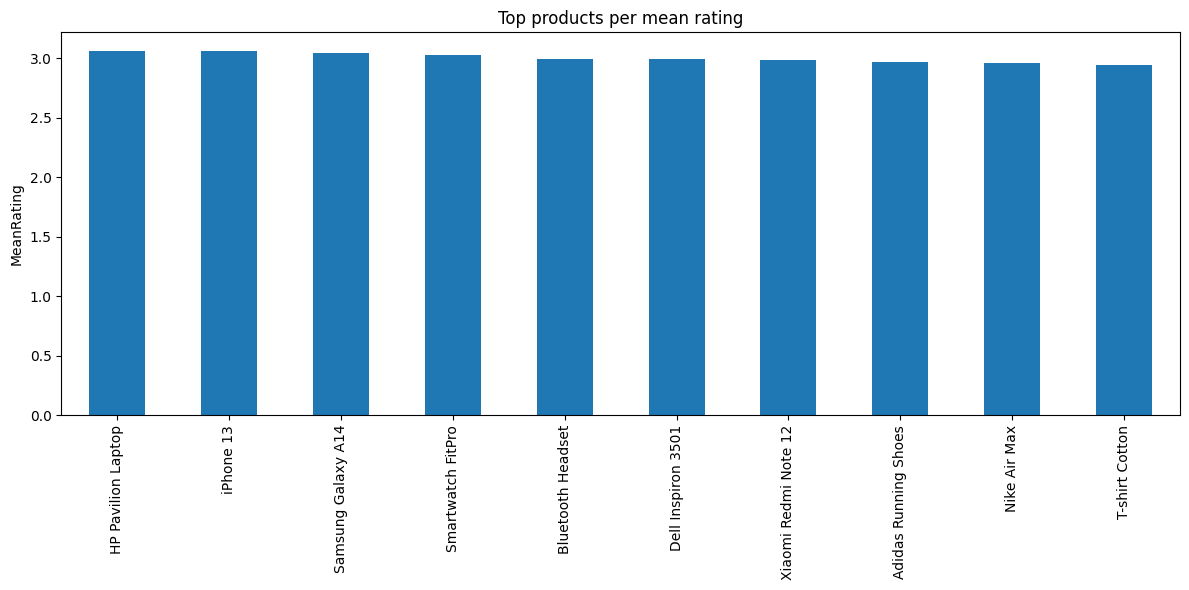

In [ ]:
ncols = len(["MeanRating"])
nrows = 1
plot_metrics(bar_plots_product_rating, nrows, ncols)

## **Top products per reviews**

In [ ]:
title_top_number_reviews_product = "Number of reviews per products"
title_top_mean_ratings_product = "Mean reviews per products"

In [ ]:
df_grouped_reviews_product = grouped_products_metrics.loc[:, [
    "Product", "NumberReviews", "MeanReviews"
]]

In [ ]:
df_top_reviews_product = df_grouped_reviews_product.sort_values(
    "NumberReviews", ascending=False).head(10)

In [ ]:
df_top_reviews_mean_product = df_grouped_reviews_product.sort_values(
    "MeanReviews", ascending=False).head(10)

In [ ]:
bar_plots_product_reviews = {
    "Top products per reviews": {
        "df": df_top_reviews_product,
        "x": "Product",
        "y": "NumberReviews",
    },
    "Top products per mean reviews": {
        "df": df_top_reviews_mean_product,
        "x": "Product",
        "y": "MeanReviews",
    },
}

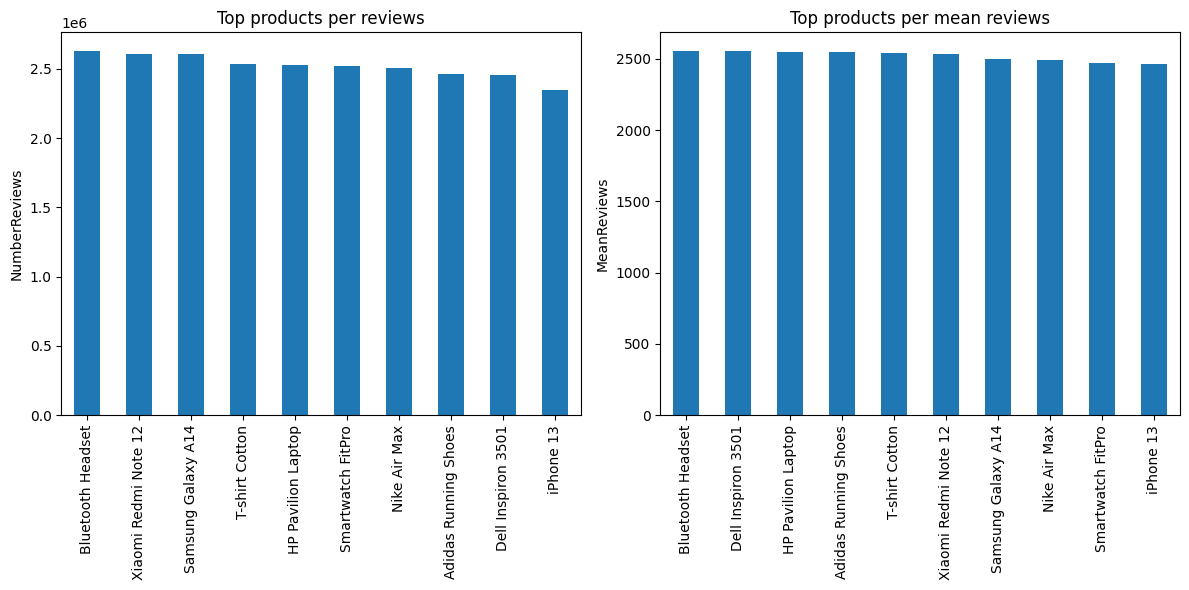

In [ ]:
plot_metrics(bar_plots_product_reviews, nrows=1, ncols=2)

# **Brand Analysis**

In [ ]:
grouped_brand_metrics = grouped_metrics(df_ecommerce,
                                           BRAND, METRICS, as_index=False)

In [ ]:
top_grouped_brand_metrics = grouped_brand_metrics.sort_values("TotalAmount", ascending=False)
top_grouped_brand_metrics

,Brand,TotalQuantity,MeanQuantity,TotalAmount,MedianAmount,MeanRating,NumberReviews,MeanReviews
9,Xiaomi,3187,3.094175,33772598.37,27123.780,2.986650,2609353,2533.352427
3,FitPro,3111,3.050000,31420413.20,24440.215,3.029706,2518191,2468.814706
7,Nike,3040,3.024876,30727637.51,24260.400,2.957343,2505699,2493.232836
4,Generic,3036,3.045135,30507500.40,24430.720,2.948756,2534748,2542.375125
0,Adidas,2904,3.000000,30269021.82,25485.760,2.968740,2464191,2545.651860
8,Samsung,3056,2.930010,30004263.23,21768.700,3.045618,2604628,2497.246405
5,HP,2979,3.006054,29482727.14,22818.800,3.066105,2526089,2549.030272
6,JBL,3043,2.957240,29200970.13,20736.160,2.996463,2632079,2557.899903
1,Apple,2793,2.924607,28550322.17,22616.660,3.064597,2350559,2461.318325
2,Dell,2913,3.028067,28060270.42,22390.900,2.992152,2455185,2552.167360


# **Platforms analysis**

In [ ]:
df_grouped_platform_metrics = grouped_metrics(df_ecommerce,
                                           PLATFORM,
                                           METRICS, as_index=False)

In [ ]:
df_top_platform_metrics = df_grouped_platform_metrics.sort_values("TotalAmount", ascending=False)

In [ ]:
df_top_platform_metrics

,Platform,TotalQuantity,MeanQuantity,TotalAmount,MedianAmount,MeanRating,NumberReviews,MeanReviews
2,Souq,10101,2.996440,1.019210e+08,23547.74,3.007840,8514542,2525.820825
1,Jumia,10105,3.024544,1.016971e+08,24140.82,2.997851,8351895,2499.818916
0,Amazon,9856,2.997567,9.837767e+07,23017.14,3.011153,8334285,2534.758212


# **Metrics accross time**

In [ ]:
metrics_orders_time = {
   "NumberOrders":("OrderID", "count")
}

orders_over_time = grouped_features(df_ecommerce, ["OrderMonth", "OrderYear"], ["OrderID"],
                                    metrics_orders_time)
orders_over_time

,OrderMonth,OrderYear,NumberOrders
0,1,2024,878
1,2,2024,775
2,3,2024,894
3,4,2024,832
4,5,2024,871
5,6,2024,788
6,7,2024,855
7,8,2024,841
8,9,2024,855
9,10,2024,858


In [ ]:
map_month = {1: "jan", 2: "feb", 3: "march", 4: "apr", 5: "may", 6:"june", 7:"jul", 8:"aug", 9:"sept", 10:"oct", 11:"nov", 12:"dec"}
order_month = [month for index, month in map_month.items()]
df_ecommerce["OrderMonthName"] = df_ecommerce["OrderMonth"].map(map_month).astype("category")
# reorder the months
df_ecommerce["OrderMonthName"] = df_ecommerce["OrderMonthName"].cat.reorder_categories(
    new_categories=order_month,
    ordered=True
)

In [ ]:
def plot_time_serie(df, x=None, y=None, title=None, ax=None):
  ax = df.plot(x=x, y=y, legend=False, ax=ax, marker="o")
  ax.set_title(title)
  ax.set_xlabel("")
  return ax

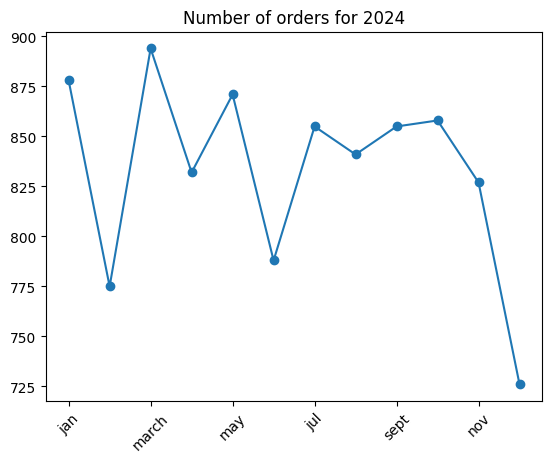

In [ ]:
orders_over_time["OrderMonthName"] = orders_over_time["OrderMonth"].map(map_month)
ax = plot_time_serie(orders_over_time,
                                   x="OrderMonthName",
                                   y="NumberOrders",
                                   title="Number of orders for 2024")
plt.xticks(rotation=45)
plt.show()

The number of orders decreased throughout the months

## **Turnover evolution throughout months**

In [ ]:
metrics_turnover = {
    "TurnoverMonth": ("TotalAmount", "sum"),
    "MeanTurnoverMonth": ("TotalAmount", "mean")
}

In [ ]:
turnover_per_month = grouped_features(df_ecommerce, "OrderMonthName", ["TotalAmount"], metrics_turnover)

/tmp/ipython-input-393979838.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby(grouped_feature, as_index=False)[numerical_feature].agg(**metrics)


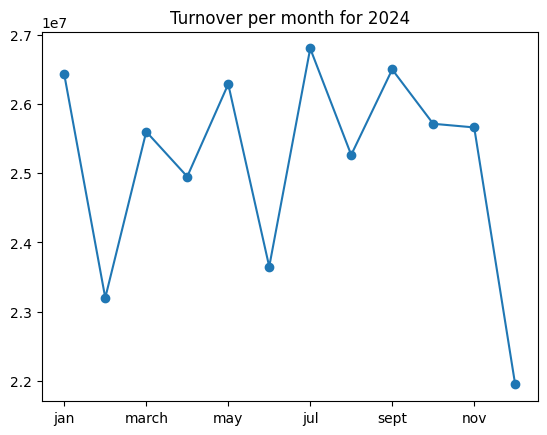

In [ ]:
turnover_per_month_plot = plot_time_serie(
    turnover_per_month,
    x="OrderMonthName",
    y="TurnoverMonth",
    title="Turnover per month for 2024")
plt.xlabel("")
plt.show()

As per the cumulated turnover per month

## **Geographical performances**

Which cities generate the most total revenue or have the highest number of orders ?

In [ ]:
metrics = {
    "TotalRevenue":("TotalAmount", "sum"),
    "NumberOrders": ("OrderID", "count"),
    "NumberProducts": ("Product", "count")
}
grouped_feature = "City"

In [ ]:
grouped_city_revenue_orders_products = grouped_features(df_ecommerce,
                                               grouped_feature,
                                               ["OrderID",
                                                "TotalAmount",
                                                "Product"],
                                               metrics)

In [ ]:
top_grouped_city_revenue = top_performer(grouped_city_revenue_orders_products,
                                                [grouped_feature, "TotalRevenue"],
                                         "TotalRevenue")

In [ ]:
top_grouped_city_orders = top_performer(grouped_city_revenue_orders_products,
                                                [grouped_feature, "NumberOrders"],
                                         "NumberOrders")

In [ ]:
top_grouped_city_products = top_performer(grouped_city_revenue_orders_products,
                                                [grouped_feature, "NumberProducts"],
                                         "NumberProducts")

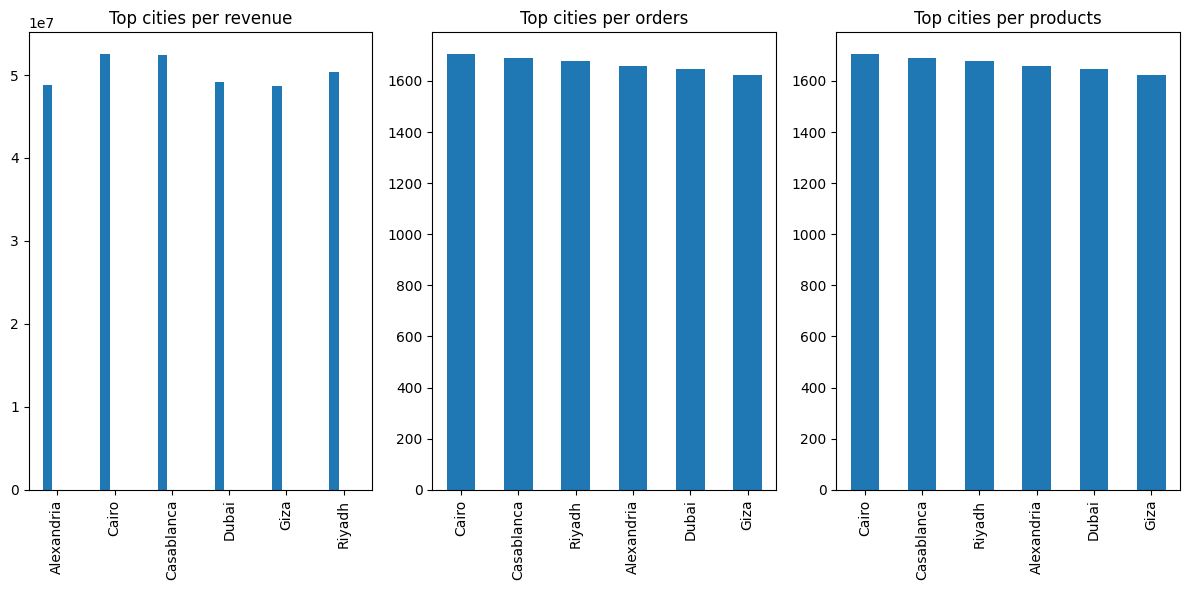

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))
plot_top_grouped_city_revenue = plot_bar_df(grouped_city_revenue_orders_products,
                                            x=grouped_feature,
                                            title="Top cities per revenue", ax=ax[0])
plot_top_grouped_city_orders = plot_bar_df(top_grouped_city_orders,
                                            x=grouped_feature,
                                            title="Top cities per orders", ax=ax[1])
plot_top_grouped_city_products = plot_bar_df(top_grouped_city_products,
                                            x=grouped_feature,
                                            title="Top cities per products", ax=ax[2])
plt.tight_layout()
plt.show()

City with the highest number of orders are also the ones with the highest revenue generated, that means it seems to have a positive correlation

Is there a difference in product preferences across different cities ?

In [ ]:
product_preferences_city = df_ecommerce.groupby(["City", "Product"], as_index=False).agg(
    NumberProducts=("Product", "count")
)

It is not that clear how data are distributed. So let's try more a pie chart per city

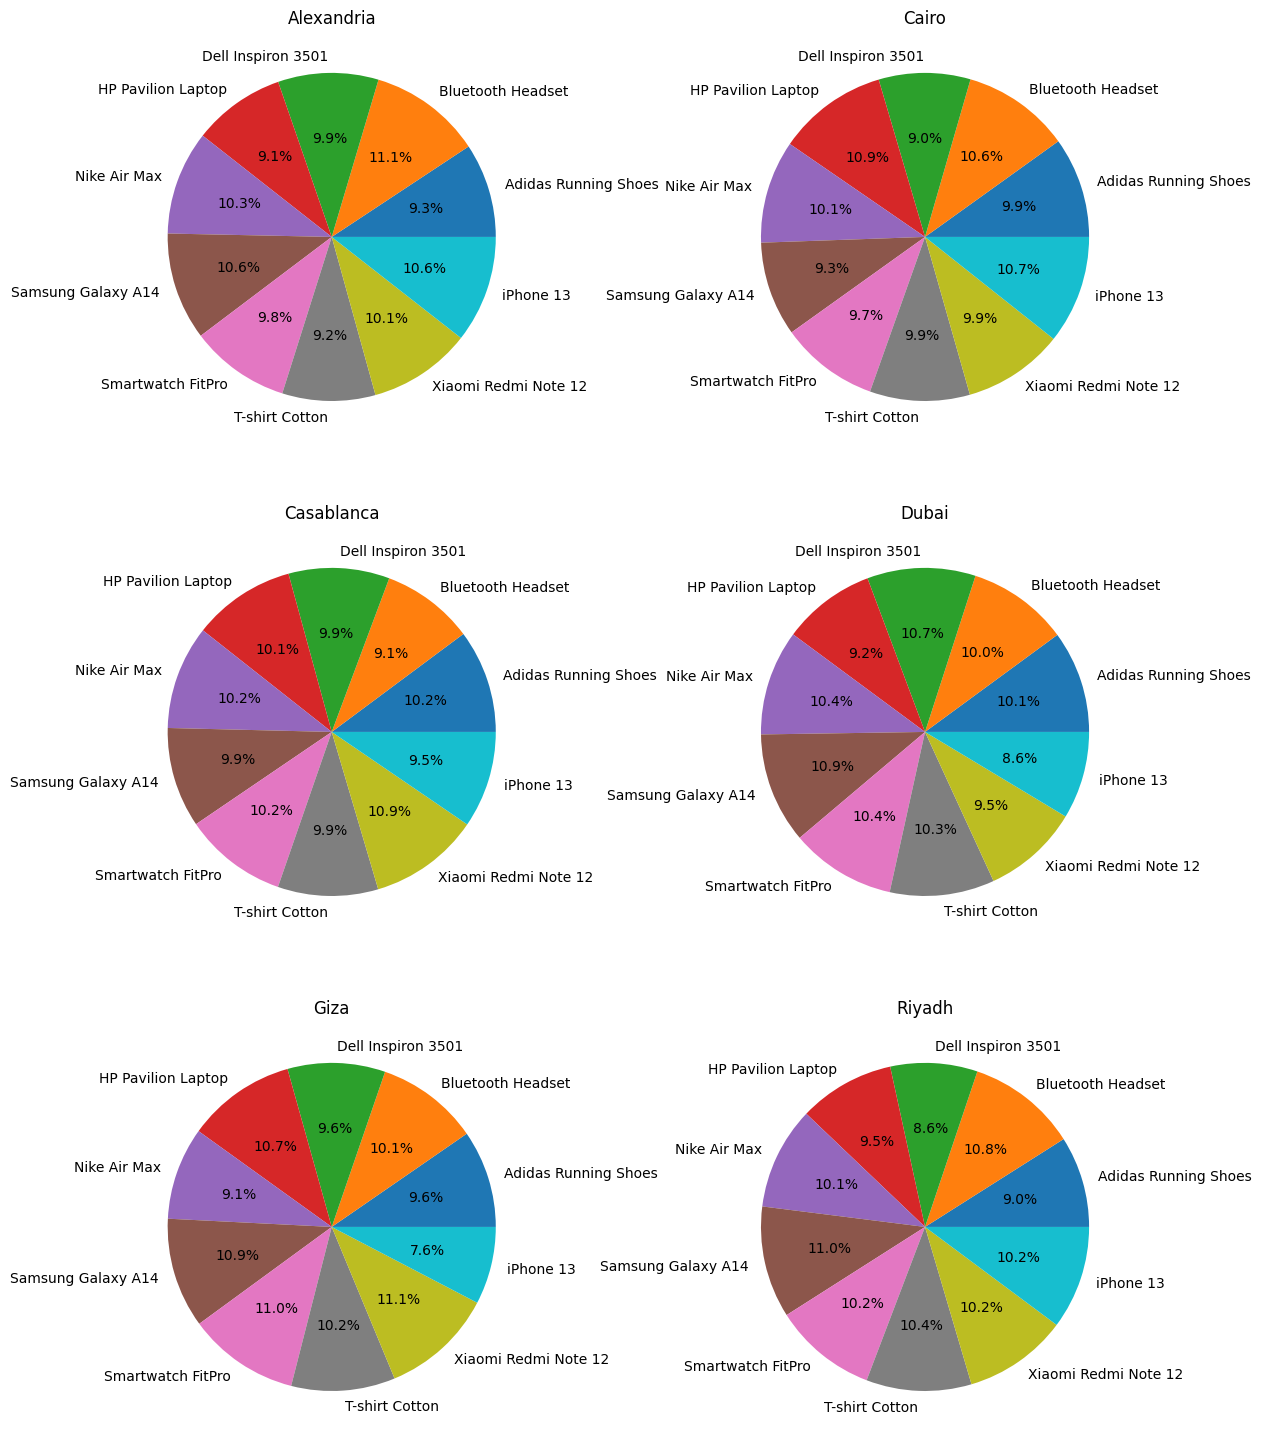

In [ ]:
import math
ncols = 2
nrows = math.ceil(product_preferences_city["City"].nunique()/ncols)

fig, axes= plt.subplots(nrows, ncols, figsize=(12, 15))
ax= axes.flatten()

for index, city in enumerate(product_preferences_city["City"].unique()):
  row_city = product_preferences_city[product_preferences_city["City"]==city]

  # plot some piecharts
  row_city.plot(kind="pie",
                y="NumberProducts",
                labels=row_city["Product"].unique(),
                autopct="%1.1f%%",
                legend=False,
                ax=ax[index])
  ax[index].set_title(city)
  ax[index].set_ylabel("")

plt.tight_layout()
plt.show()

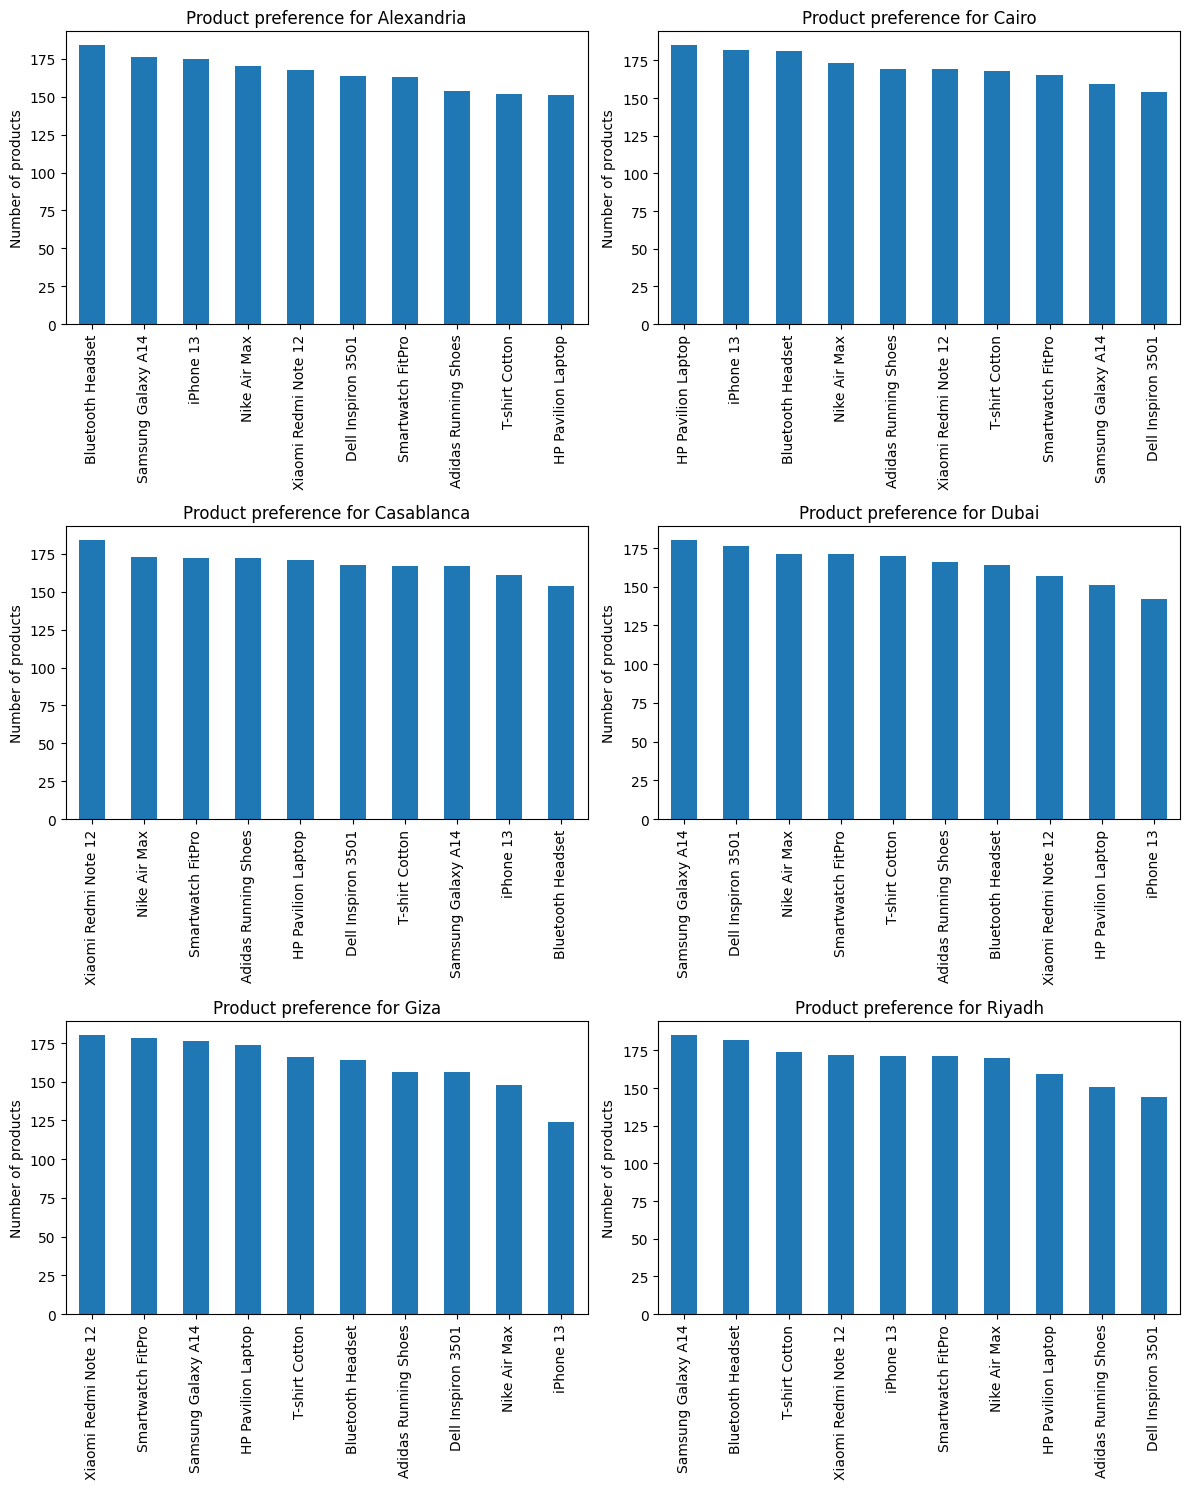

In [ ]:
fig, axes= plt.subplots(nrows, ncols, figsize=(12, 15))
ax= axes.flatten()

for index, city in enumerate(product_preferences_city["City"].unique()):
  row_city = product_preferences_city[product_preferences_city["City"]==city]
  row_city_srt = top_performer(
      row_city,
      ["City", "Product", "NumberProducts"],
      "NumberProducts"
  )

  # plot some barcharts
  row_city_plot = plot_bar_df(
      row_city_srt,
      x="Product",
      ax=ax[index]
  )
  ax[index].set_title(city)
  ax[index].set_xlabel("")
  ax[index].set_ylabel("Number of products")
  ax[index].set_title(f"Product preference for {city}")
plt.tight_layout()
plt.show()

# **Market Basket Analysis**

In [ ]:
grouped_orders = df_ecommerce.groupby("OrderID", as_index=False)

# **Correlations between Reviews/Ratings and Sales**

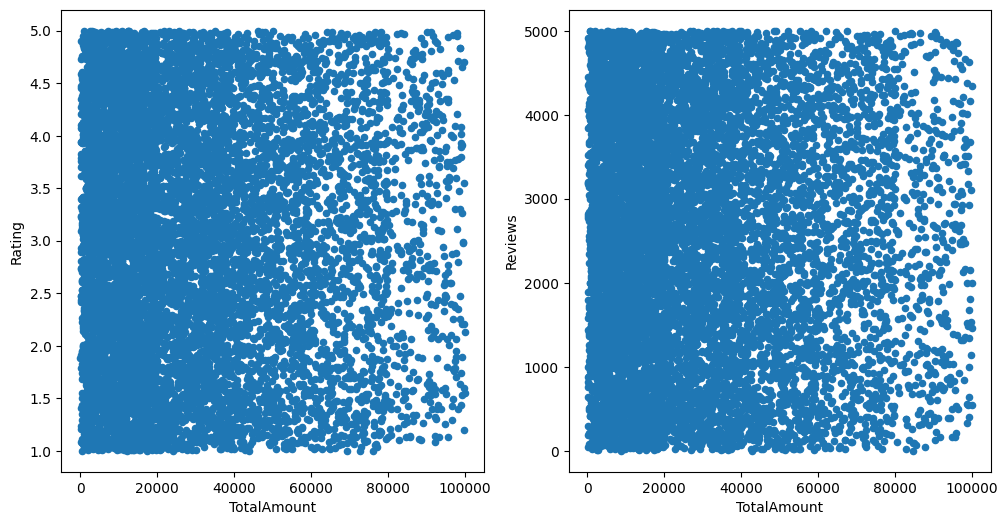

In [ ]:
# loop to build a scatterplot between reviews/ratings and sales
ratings_reviews = ["Rating", "Reviews"]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for i, value in enumerate(ratings_reviews):
  df_ecommerce.plot(
      kind="scatter",
      x="TotalAmount",
      y=value,
      ax=ax[i]
  )

## **Do products with higher ratings and more reviews tends to have higher sales amount**

In [ ]:
rating_reviews_product_metrics = [PRODUCT] + ["MeanRating", "NumberReviews", "MeanReviews"]

In [ ]:
grouped_rating_reviews_products = grouped_products_metrics.loc[:, rating_reviews_product_metrics]

In [ ]:
srt_rating_reviews_products = grouped_rating_reviews_products.sort_values(["NumberReviews", "MeanRating"], ascending=False)
srt_rating_reviews_products

,Product,MeanRating,NumberReviews,MeanReviews
1,Bluetooth Headset,2.996463,2632079,2557.899903
8,Xiaomi Redmi Note 12,2.986650,2609353,2533.352427
5,Samsung Galaxy A14,3.045618,2604628,2497.246405
7,T-shirt Cotton,2.948756,2534748,2542.375125
3,HP Pavilion Laptop,3.066105,2526089,2549.030272
6,Smartwatch FitPro,3.029706,2518191,2468.814706
4,Nike Air Max,2.957343,2505699,2493.232836
0,Adidas Running Shoes,2.968740,2464191,2545.651860
2,Dell Inspiron 3501,2.992152,2455185,2552.167360
9,iPhone 13,3.064597,2350559,2461.318325


Different groups with higher number of reviews and mean rating to total sales amount

As we have numerical and categorical values and a numerical outcome to compare multiple groups, we will use - what we call ANCOVA

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols(
    "TotalAmount ~ C(Product) + Rating + Reviews + C(Product):Rating + C(Product):Reviews",
    data=df_ecommerce
).fit()

# Build the different groups


In [ ]:
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                          sum_sq      df         F    PR(>F)
C(Product)          1.554991e+10     9.0  3.039907  0.001233
Rating              2.115167e+06     1.0  0.003722  0.951357
C(Product):Rating   4.552026e+09     9.0  0.889891  0.533278
Reviews             3.187187e+08     1.0  0.560767  0.453969
C(Product):Reviews  6.304638e+09     9.0  1.232516  0.269566
Residual            5.666572e+12  9970.0       NaN       NaN


- PR(>F) Products < 0.05: products have an influence on the totalAmount
- PR(>F) Rating > 0.05: no influence on the totalAmount
- PR(>F) Reviews > 0.05: no influence on the totalAmount

That confirms our first visualisations that higher number of reviews and mean ratins do not mean that sales will increase.

In [ ]:
model.fittedvalues

,0
0,30079.460628
1,29716.302831
2,29167.377626
3,29560.337422
4,30010.053725
...,...
9995,30383.486798
9996,31208.421551
9997,31457.338688
9998,32346.876644


In [ ]:
residuals = model.resid

Let's see how residuals and fitted values behave and vary from each others

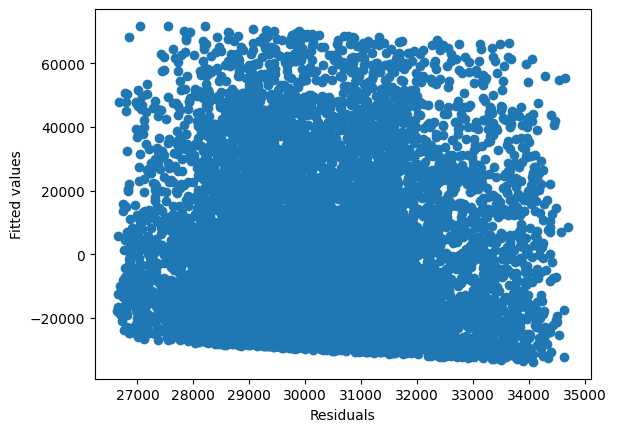

In [ ]:
plt.scatter(
    x=model.fittedvalues,
    y=residuals
)
plt.xlabel("Residuals")
plt.ylabel("Fitted values")
plt.show()

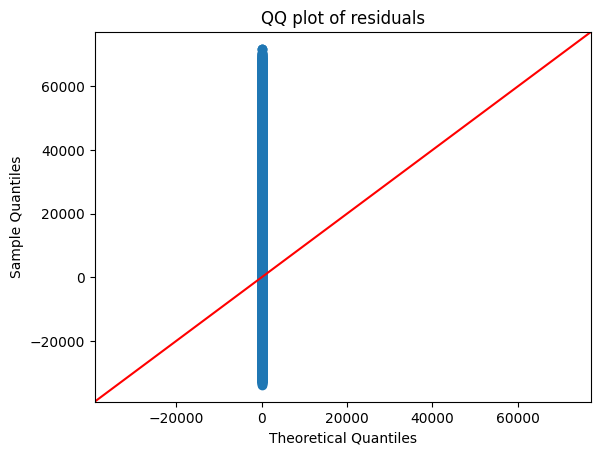

In [ ]:
sm.qqplot(residuals, line="45")
plt.title("QQ plot of residuals")
plt.show()

# **Building model predictions**

- Target: Rating - numerical continuous data
- Model to perform: Regressor
- Models availables: DecisionTreeRegression, RandomForestRegression, LinearRegression, KNN

In [ ]:
# date feature removal + unique order id that would create too much dummy features as there are 10K unique values
df_ecommerce_pred_model = df_ecommerce.drop(["OrderID",
                                             ], axis=1)

In [ ]:
numerical_features_model = df_ecommerce_pred_model.select_dtypes(
    include="number"
).columns.tolist()
numerical_features_model

['Price',
 'Quantity',
 'TotalAmount',
 'Rating',
 'Reviews',
 'OrderMonth',
 'OrderYear']

In [ ]:
categorical_features_model = df_ecommerce_pred_model.select_dtypes(
    include="object"
).columns.tolist()
categorical_features_model

['Product', 'Category', 'Brand', 'Platform', 'City']

In [ ]:
date_features_model = df_ecommerce_pred_model.select_dtypes(
    include="datetime"
).columns.tolist()
date_features_model

['OrderDate']

Let's see now how numerical features correlate between themselves

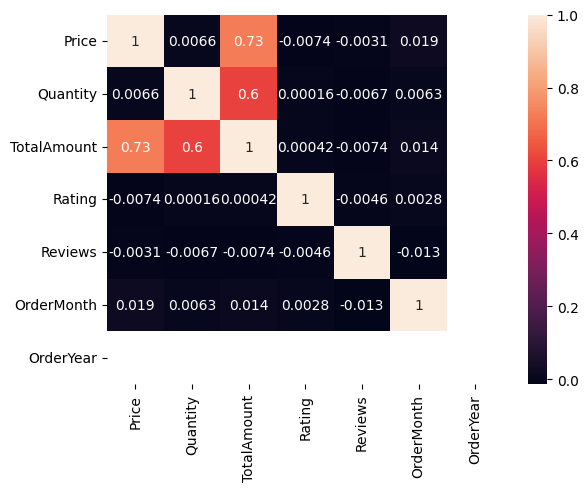

In [ ]:
sns.heatmap(df_ecommerce_pred_model[numerical_features_model].corr(), annot=True)
plt.show()

No correlations appear between features and rating, that might cause false predictive rating data.
We will try to perform it though to make sure that our assumption is confirmed.

In [ ]:
ecommerce_pred_model_dummies = pd.get_dummies(df_ecommerce_pred_model[categorical_features_model], drop_first=True)

In [ ]:
df_ecommerce_pred_model_dummies = pd.concat([df_ecommerce_pred_model[numerical_features_model], ecommerce_pred_model_dummies], axis=1)

In [ ]:
df_ecommerce_pred_model_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Price                         10000 non-null  float64
 1   Quantity                      10000 non-null  int64  
 2   TotalAmount                   10000 non-null  float64
 3   Rating                        10000 non-null  float64
 4   Reviews                       10000 non-null  int64  
 5   OrderMonth                    10000 non-null  int32  
 6   OrderYear                     10000 non-null  int32  
 7   Product_Bluetooth Headset     10000 non-null  bool   
 8   Product_Dell Inspiron 3501    10000 non-null  bool   
 9   Product_HP Pavilion Laptop    10000 non-null  bool   
 10  Product_Nike Air Max          10000 non-null  bool   
 11  Product_Samsung Galaxy A14    10000 non-null  bool   
 12  Product_Smartwatch FitPro     10000 non-null  bool   
 13  Pr

In [ ]:
df_ecommerce_pred_model_dummies.head()

,Price,Quantity,TotalAmount,Rating,Reviews,OrderMonth,OrderYear,Product_Bluetooth Headset,Product_Dell Inspiron 3501,Product_HP Pavilion Laptop,...,Brand_Nike,Brand_Samsung,Brand_Xiaomi,Platform_Jumia,Platform_Souq,City_Cairo,City_Casablanca,City_Dubai,City_Giza,City_Riyadh
0,16284.02,1,16284.02,1.39,1684,11,2024,False,False,False,...,False,True,False,False,True,True,False,False,False,False
1,6645.20,2,13290.40,2.56,3604,6,2024,False,False,False,...,True,False,False,True,False,False,False,False,False,False
2,8882.92,3,26648.76,4.98,1257,5,2024,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,3665.44,1,3665.44,1.44,662,7,2024,False,False,True,...,False,False,False,False,True,False,False,True,False,False
4,5210.37,2,10420.74,3.73,2424,2,2024,False,False,False,...,False,False,False,False,True,False,True,False,False,False


Once our dataframe is ready to be run and performed by the model, we will then split the data between the training dataframe and the target

In [ ]:
# Build a dataframe mixing true data and predicted ones
def df_pred_true(y_true, y_pred):
  return pd.DataFrame({
      "y_true": y_true,
      "y_pred": y_pred,
      "difference": abs(y_true-y_pred)
  })

In [ ]:
# Build a scatter plot
def scatter_pred_true(df=None, feature_true=None, feature_pred=None, y_true=None, y_pred=None):
  if df is not None:
    x = df[feature_true]
    y = df[feature_pred]
  else:
    x = y_true
    y= y_pred

  plt.scatter(x, y)
  plt.xlabel("True values")
  plt.ylabel("Predicted values")
  plt.show()

In [ ]:
def split_data_target(df, target):
  X = df.drop(target, axis=1)
  y = df[target]
  return X, y

In [ ]:
def train_test_model(X, y,  mode=None, test_size=None):
  if mode == "None":
    mode == "continuous"
    stratify=None
  else:
    stratify=y

  if test_size is None:
    size=0.2
  else:
    size=test_size

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=42, stratify=stratify)

  return X_train, X_test, y_train, y_test

In [ ]:
X, y = split_data_target(df_ecommerce_pred_model_dummies, "Rating")

In [ ]:
X_train, X_test, y_train, y_test = train_test_model(X, y)

Once the training vlaues are done, we can now process to scale and perform the model

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

A robust scale will be performed as it better handle the outliers using the median instead of the mean value.

In [ ]:
supervised_models = {
    "pipeLinearRegression":
        Pipeline([
            ("robustScaler", RobustScaler()),
            ("model", LinearRegression())
        ]),
    "pipeDecisionTreeRegression":
        Pipeline([
            ("model", DecisionTreeRegressor())
        ]),
    "pipeRandomForestRegressor":
        Pipeline([
            ("model", RandomForestRegressor())
        ])
}

In [ ]:
parameters_models = {
    "pipeLinearRegression": {},
    "pipeDecisionTreeRegression": {
        "model__max_depth": [None, 5, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 5],
    },
    "pipeRandomForestRegressor": {
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 10]
    }
}

In [ ]:
def evaluate_best_training_model(supervised_models):
  training_results = {}
  for name, model in supervised_models.items():
    training_result = GridSearchCV(estimator=model,
                                  param_grid=parameters_models[name],
                                  cv=3, scoring="r2", n_jobs=-1)
    training_result.fit(X_train, y_train)
    best_estimator = training_result.best_estimator_
    best_params = training_result.best_params_
    best_score = training_result.best_score_

    training_results[name] = {
        "best_model_name": name,
        "best_estimator": best_estimator,
        "best_params": best_params,
        "best_score": best_score
    }
    return training_results

In [ ]:
def predicted_numeric_score_model(y_test, y_pred):
  return ({
      "r2_score": r2_score(y_test, y_pred),
      "mae_score": mean_absolute_error(y_test, y_pred),
      "rmse_score": root_mean_squared_error(y_test, y_pred)
  })

## **Predict the rating feature**

Model evaluation with Grid Search CV

In [ ]:
training_results_ratings = evaluate_best_training_model(supervised_models)

In [ ]:
best_rating_training_model = max(training_results_ratings, key=lambda name: training_results_ratings[name]["best_score"])
best_rating_training_model_results = training_results_ratings[best_rating_training_model]

In [ ]:
best_rating_training_model_results

{'best_model_name': 'pipeLinearRegression',
 'best_estimator': Pipeline(steps=[('robustScaler', RobustScaler()),
                 ('model', LinearRegression())]),
 'best_params': {},
 'best_score': np.float64(-0.004778912895449035)}

In [ ]:
print(f"The best training model evaluated through a GridSearchCV is {best_rating_training_model_results['best_model_name']}")

The best training model evaluated through a GridSearchCV is pipeLinearRegression


In [ ]:
best_model_rating = best_rating_training_model_results["best_estimator"]
best_model_rating

Pipeline(steps=[('robustScaler', RobustScaler()),
                ('model', LinearRegression())])

In [ ]:
best_model_rating.fit(X_train, y_train)

y_pred = best_model_rating.predict(X_test)
scores_rating = predicted_numeric_score_model(y_test, y_pred)

In [ ]:
for name, score_rating in scores_rating.items():
  print(f"{name} - score: {score_rating:.4f}")

r2_score - score: -0.0021
mae_score - score: 1.0001
rmse_score - score: 1.1561


R2 closed to 0 and MAE closed to 1, that means the models is completely inapropriate as it cannot catch the patterm between those two features.

In [ ]:
df_pred_true(y_test, y_pred)

,y_true,y_pred,difference
5328,2.04,3.000418,0.960418
519,1.20,3.082788,1.882788
5761,4.55,3.089273,1.460727
3895,1.91,2.920273,1.010273
4410,2.74,2.899237,0.159237
...,...,...,...
7140,3.46,3.013627,0.446373
1027,3.44,2.994572,0.445428
6749,1.52,3.096432,1.576432
8198,4.56,3.017758,1.542242


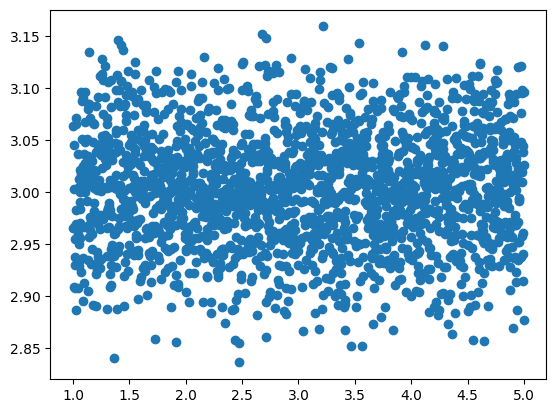

In [ ]:
plt.scatter(x=y_test, y=y_pred)
plt.show()

Vizually, no pattern can be observed over the scatter plot. That confirm our initial assumption that features do not provide sufficient information to accurately predict the "Rating"

## **Predict the "price" feature**

In [ ]:
df_ecommerce_pred_model_dummies_price = df_ecommerce_pred_model_dummies.drop(["Quantity", "TotalAmount", "OrderMonth", "OrderYear"], axis=1)

In [ ]:
X_price, y_price = split_data_target(df_ecommerce_pred_model_dummies_price, "Rating")

In [ ]:
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price
)

In [ ]:
train_price_results = evaluate_best_training_model(supervised_models)

# Find the overall best model across all supervised_models
best_model_name_price = max(train_price_results, key=lambda name: train_price_results[name]['best_score'])
best_price_model_info = train_price_results[best_model_name_price]

best_model_price = best_price_model_info["best_estimator"]

In [ ]:
best_price_model_info

{'best_model_name': 'pipeLinearRegression',
 'best_estimator': Pipeline(steps=[('robustScaler', RobustScaler()),
                 ('model', LinearRegression())]),
 'best_params': {},
 'best_score': np.float64(-0.004778912895449035)}

In [ ]:
best_model_price = best_price_model_info["best_estimator"]

In [ ]:
best_model_price.fit(X_train_price, y_train_price)
y_pred_price = best_model_price.predict(X_test_price)

scores_price = predicted_numeric_score_model(y_test_price, y_pred_price)

In [ ]:
for name, score_price in scores_price.items():
  print(f"{name} - score: {score_price:.4f}")

r2_score - score: -0.0033
mae_score - score: 0.9982
rmse_score - score: 1.1550


MAE closed to 1, 100% of chance to make a false prediction.

In [ ]:
df_pred_true_price = df_pred_true(y_test_price, y_pred_price)
df_pred_true_price

,y_true,y_pred,difference
6252,2.96,2.957671,0.002329
4684,1.76,2.931934,1.171934
1731,1.74,3.086017,1.346017
4742,2.34,3.052909,0.712909
4521,3.93,3.020734,0.909266
...,...,...,...
6412,3.29,3.028691,0.261309
8285,2.78,2.978356,0.198356
7853,4.77,2.935981,1.834019
1095,3.02,2.944829,0.075171


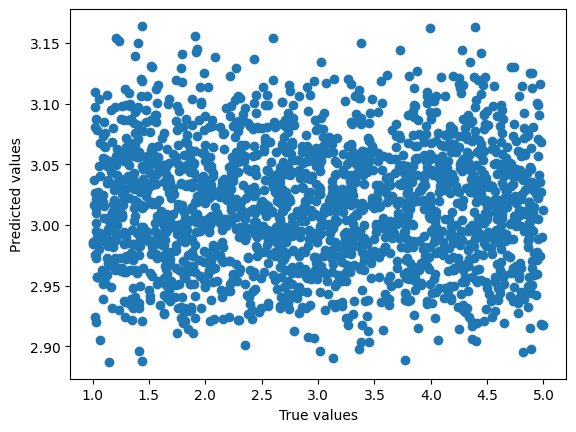

In [ ]:
scatter_pred_true(df_pred_true_price, "y_true", "y_pred")

As for continuous variable prediction, models often rely heavily in features that are strongly correlated with the target, removing those last ones does not allow the model to find any relationship to exploit and then significantly drop.

That's why; based on currents samples, predicting features like rating or price are not that accurate, because no relationship exist for the rating feature and the price can be found by using math calculation between TotalAmount and Quantity (TotalAmount / Quantity = Price)

## **Can the number of reviews influence the amount ?**

The two features are numerical-based data and are independent.
So stats tests to perform remain mainly spearman or Pearson

Our hypothesis are as following:
- H0: Reviews and amount are correlated
- H1: Reviews and amount are independent

In [ ]:
H0 = "Reviews and amount are independent"
H1 = "Reviews and amount are correlated"

In [ ]:
reviews_amount_features = ["Reviews", "TotalAmount"]

In [ ]:
df_reviews_features = df_ecommerce.loc[:, reviews_amount_features]

**Check the distribution ?**

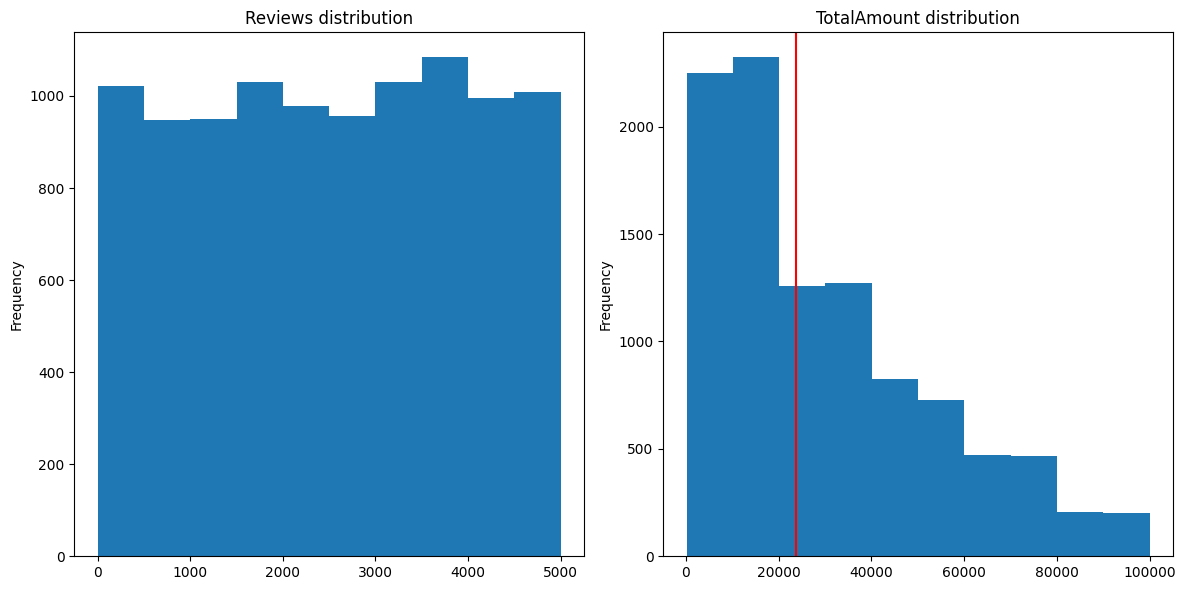

In [ ]:
# See the distribution
fig, axes = plt.subplots(1, len(reviews_amount_features), figsize=(12, 6))
for i, col in enumerate(reviews_amount_features):
  df_reviews_features[reviews_amount_features[i]].plot(kind="hist", ax=axes[i])
  axes[i].set_title(f"{col} distribution")
  if col == reviews_amount_features[-1]:
    plt.axvline(df_reviews_features[col].median(), color="red")
plt.tight_layout()
plt.show()

Total Amount is a bit skewed because there are some outliers observed

In [ ]:
df_reviews_features.describe()

,Reviews,TotalAmount
count,10000.000000,10000.000000
mean,2520.072200,30199.572439
std,1443.849734,23861.789828
min,0.000000,113.550000
25%,1275.000000,11066.910000
50%,2537.500000,23671.630000
75%,3767.000000,44648.580000
max,5000.000000,99993.800000


How many extreme outliers can we observe ?

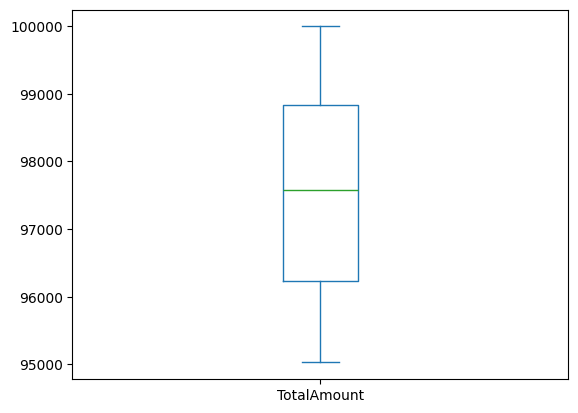

In [ ]:
if outliers_amount.empty:
  raise Exception("No data to plot")
outliers_amount.plot(kind="box")
plt.show()

In [ ]:
outliers_amount.describe()

,TotalAmount
count,89.000000
mean,97510.808427
std,1495.158576
min,95028.950000
25%,96227.500000
50%,97579.000000
75%,98828.650000
max,99993.800000


In [ ]:
extreme_outliers_amount = df_reviews_features.loc[df_reviews_features["TotalAmount"] > upper_whiskers + (1.5 * iqr_amount), "TotalAmount"]

In [ ]:
if extreme_outliers_amount.empty:
  print("No data to plot")
else:
  extreme_outliers_amount.plot(kind="box")

No data to plot


No extreme outliers to display

**Is there a correlation ?**

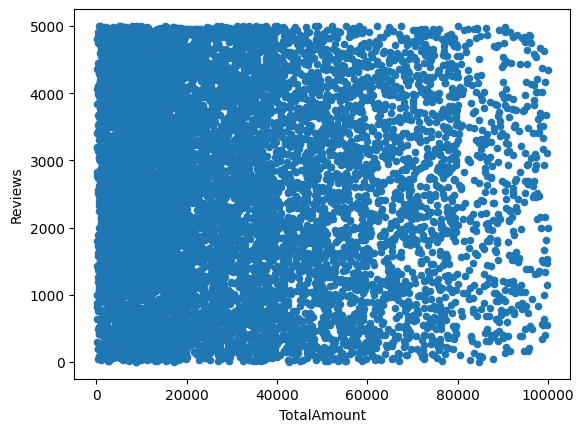

In [ ]:
# see the correlations between total amount and reviews
df_reviews_features.plot(kind="scatter", x="TotalAmount", y="Reviews")
plt.show()

In [ ]:
df_reviews_features["TotalAmount"].corr(df_reviews_features["Reviews"])

np.float64(-0.007360156600465909)

No correlations seem to be observed between the Total Amount and the reviews

When we have skewed, it is usually safer to use spearman less sensitive to outliers

In [ ]:
from scipy.stats import spearmanr
stats, pvalue = spearmanr(
    df_reviews_features[reviews_amount_features[0]],
    df_reviews_features[reviews_amount_features[1]])

In [ ]:
if pvalue < 0.05:
  print(H1)
else:
  print(H0)

Reviews and amount are independent


So because statistical test prevent us to establish a clear relationship between those two features.